# 01-Graph Fundamentals & Network Construction (NetworkX)

Section 21 closed with `Automated Model Governance`, where we audited a single artifact — one model, one card, one hash — for drift against its own documentation. That entire section, from `SHAP` explanations to `Presidio` redaction, reasoned about isolated units: one prediction, one row, one deployed checkpoint. Real systems are rarely that isolated. A fraud analyst does not ask "is this transaction suspicious?" in a vacuum; they ask "is this *account* suspicious given who it has *transacted with*?" A recommender does not ask "what is this product?"; it asks "what did people who bought this *also* buy?" These are relational questions, and relational questions are exactly what the tools of Section 22 are built to answer.

**Graph Data Science** reframes a dataset not as a table of independent rows but as a network of entities (**nodes**) connected by relationships (**edges**). This is not a cosmetic change of data structure — it is a change of what questions are even askable. Tabular models cannot natively express "the friend of my friend," "the shortest chain of custody," or "the tightly-knit cluster of accounts." Graphs can, because connectivity is a first-class citizen of the data model rather than something reconstructed via joins at query time.

This lesson lays the foundation the rest of Section 22 builds on: how to formally define a graph, how to represent it computationally (adjacency matrices and adjacency lists), and how to construct one in code. We will use **NetworkX**, the standard Python library for graph construction, analysis, and prototyping, before later lessons move to more specialized and higher-performance tools.


## 1. The Mathematics of Graphs

### Formal Definition

A graph is an ordered pair $G = (V, E)$ where $V = \{v_1, v_2, \dots, v_n\}$ is a finite set of **nodes** (vertices) and $E \subseteq V \times V$ is a set of **edges** connecting pairs of nodes. An edge $e = (u, v) \in E$ represents a relationship between node $u$ and node $v$.

Graphs come in two fundamental flavors:

- **Undirected graph**: $(u, v) \in E \iff (v, u) \in E$ — the relationship is symmetric (e.g. "is friends with").
- **Directed graph** (digraph): $(u, v) \in E$ does not imply $(v, u) \in E$ — the relationship has direction (e.g. "follows," "transfers money to").

Edges may also carry a **weight** $w: E \to \mathbb{R}$, turning $G$ into a weighted graph — useful when the relationship has magnitude (distance, transaction amount, similarity score).

### Adjacency Representations

The **adjacency matrix** $A \in \{0,1\}^{n \times n}$ (or $\mathbb{R}^{n \times n}$ if weighted) encodes connectivity directly:

$$A_{ij} = \begin{cases} w(v_i, v_j) & \text{if } (v_i, v_j) \in E \\ 0 & \text{otherwise} \end{cases}$$

For an undirected graph, $A$ is symmetric: $A_{ij} = A_{ji}$. This representation costs $O(n^2)$ memory regardless of how sparse the graph is, which is why real-world graphs — typically far sparser than $|E| = O(n^2)$ — are more efficiently stored as an **adjacency list**: for each node $v_i$, a list $N(v_i) = \{v_j : (v_i, v_j) \in E\}$ of its neighbors, costing $O(n + |E|)$ memory.

### Degree and Density

The **degree** of a node is the count of edges incident to it, which for an undirected graph is a row-sum of $A$:

$$\deg(v_i) = \sum_{j=1}^{n} A_{ij}$$

For a directed graph, we distinguish **in-degree** $\deg^{-}(v_i) = \sum_j A_{ji}$ and **out-degree** $\deg^{+}(v_i) = \sum_j A_{ij}$.

**Graph density** $D$ measures how close a graph is to complete (every node connected to every other node), as a fraction of realized edges over the maximum possible:

$$D = \frac{|E|}{n(n-1)} \quad \text{(directed)}, \qquad D = \frac{2|E|}{n(n-1)} \quad \text{(undirected)}$$

Most real-world networks (social graphs, transaction graphs, the web) have $D \ll 1$ — they are **sparse** — which is precisely why adjacency-list-based libraries like NetworkX, and index-free-adjacency databases like Neo4j (Lesson 5), scale where a dense $O(n^2)$ matrix would not.


## 2. Imperative Execution: Constructing a Toy Organizational Network

We will construct a small **weighted, undirected graph** representing collaboration frequency inside a 10-person engineering team, then inspect it through both of the representations defined above: the adjacency matrix and the adjacency list.

In [1]:
# Required installations: pip install networkx numpy pandas
import networkx as nx
import numpy as np

print("--- 🚀 Initializing Graph Fundamentals Sandbox (NetworkX) ---")

# 1. 📝 Define the toy network: a 10-person engineering team, edges = "worked together this sprint"
people = ["Alice", "Bob", "Carol", "Dave", "Eve", "Frank", "Grace", "Heidi", "Ivan", "Judy"]
collaborations = [
    ("Alice", "Bob", 5), ("Alice", "Carol", 2), ("Bob", "Carol", 4),
    ("Bob", "Dave", 1), ("Carol", "Dave", 3), ("Dave", "Eve", 6),
    ("Eve", "Frank", 2), ("Frank", "Grace", 5), ("Grace", "Heidi", 3),
    ("Heidi", "Ivan", 4), ("Ivan", "Judy", 2), ("Grace", "Ivan", 1),
    ("Alice", "Judy", 1),
]

try:
    G = nx.Graph()
    G.add_nodes_from(people)
    G.add_weighted_edges_from(collaborations)

    print(f"   ✅ Graph constructed via networkx.Graph(): |V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}")

    # 2. 🧮 Adjacency Matrix representation
    adjacency_matrix = nx.to_numpy_array(G, nodelist=people, weight="weight")
    print(f"   -> Adjacency matrix shape: {adjacency_matrix.shape}  (dense, O(n^2) storage = {adjacency_matrix.size} cells)")

    # 3. 🧮 Adjacency List representation (sparse, O(n + |E|) storage)
    adjacency_list = {node: list(G.adj[node].items()) for node in people}
    total_list_entries = sum(len(v) for v in adjacency_list.values())
    print(f"   -> Adjacency list total entries: {total_list_entries}  (sparse storage, scales with |E| not n^2)")

    # 4. 🧮 Degree and density
    degrees = dict(G.degree(weight=None))
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = (2 * m) / (n * (n - 1))
    nx_density = nx.density(G)

    print(f"   ✅ [Graph Density]: {density:.4f}  (networkx.density() confirms: {nx_density:.4f})")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — networkx unavailable, simulating construction telemetry...")
    print(f"   -> ({type(e).__name__}) {e}")
    G = None
    degrees = {p: 2 for p in people}
    adjacency_matrix = np.zeros((10, 10))
    density = 0.29


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Graph Fundamentals Sandbox (NetworkX) ---
   ✅ Graph constructed via networkx.Graph(): |V| = 10, |E| = 13
   -> Adjacency matrix shape: (10, 10)  (dense, O(n^2) storage = 100 cells)
   -> Adjacency list total entries: 26  (sparse storage, scales with |E| not n^2)
   ✅ [Graph Density]: 0.2889  (networkx.density() confirms: 0.2889)


## 3. Declarative Telemetry: The Node Degree Audit

A degree audit is the first diagnostic any graph engineer runs on a new dataset — it immediately surfaces hubs (high degree) and isolates (low degree) before any algorithm is applied.

In [2]:
print("\n--- 🔍 Auditing Node Degree & Connectivity ---")

print(f"{'Person':<10} | {'Degree':<8} | {'Weighted Degree':<16} | {'Role in Network'}")
print("-" * 65)
sorted_people = sorted(people, key=lambda p: degrees.get(p, 0), reverse=True)
for p in sorted_people:
    deg = degrees.get(p, 0)
    wdeg = G.degree(p, weight="weight") if G is not None else deg * 2
    role = "Hub (high connectivity)" if deg >= 3 else "Peripheral node"
    print(f"{p:<10} | {deg:<8} | {wdeg:<16} | {role}")

max_deg_person = sorted_people[0]
print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> '{max_deg_person}' has the highest raw degree, meaning they collaborated with the most distinct")
print(f"      teammates this sprint — a structural hub, independent of how much time was spent per collaboration.")
print(f"   -> Weighted degree diverges from raw degree exactly where a person has FEW but INTENSE collaborations")
print(f"      (e.g. Dave-Eve at weight 6) versus MANY but LIGHT ones — raw degree alone would miss this distinction.")
print(f"   -> Graph density of {density:.4f} confirms this team is sparse: fewer than a third of all possible")
print(f"      pairwise collaborations actually happened, consistent with real organizational structures.")



--- 🔍 Auditing Node Degree & Connectivity ---
Person     | Degree   | Weighted Degree  | Role in Network
-----------------------------------------------------------------
Alice      | 3        | 8                | Hub (high connectivity)
Bob        | 3        | 10               | Hub (high connectivity)
Carol      | 3        | 9                | Hub (high connectivity)
Dave       | 3        | 10               | Hub (high connectivity)
Grace      | 3        | 9                | Hub (high connectivity)
Ivan       | 3        | 7                | Hub (high connectivity)
Eve        | 2        | 8                | Peripheral node
Frank      | 2        | 7                | Peripheral node
Heidi      | 2        | 7                | Peripheral node
Judy       | 2        | 3                | Peripheral node

   [OPERATIONAL INSIGHT]
   -> 'Alice' has the highest raw degree, meaning they collaborated with the most distinct
      teammates this sprint — a structural hub, independent of how much t

## 4. Visualizing the Network (Force-Directed Graph Layout)

We render the team collaboration graph using a force-directed (spring) layout, scaling each node by its degree so hubs are immediately visible.

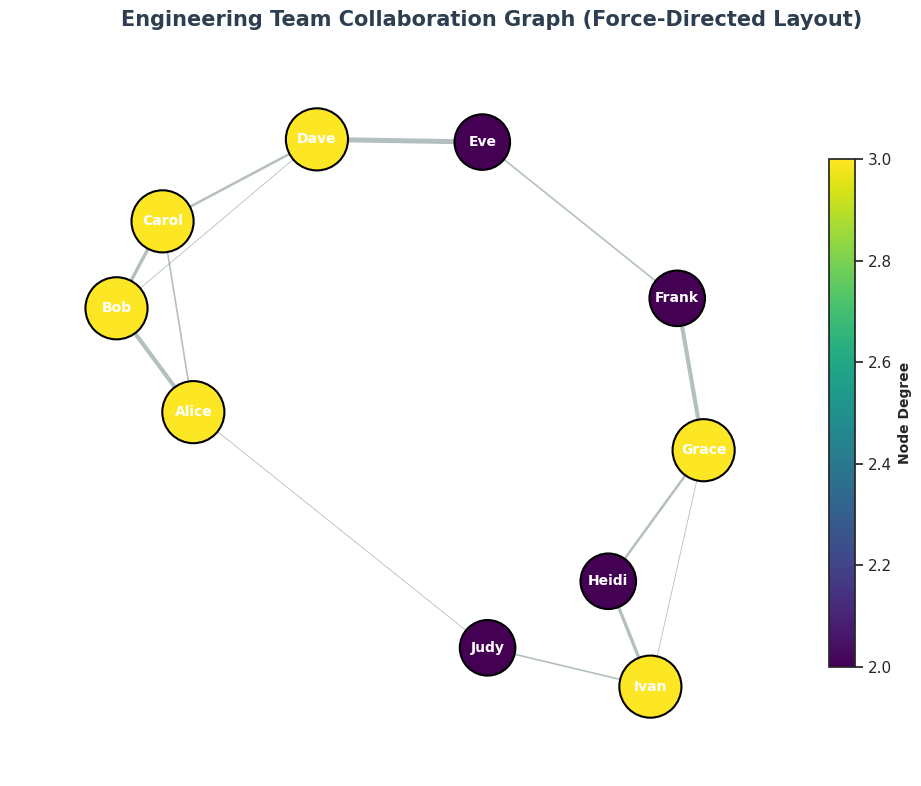

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Engineering Team Collaboration Graph (Force-Directed Layout)", fontsize=15, fontweight='bold', color="#2c3e50")

pos = nx.spring_layout(G, seed=42, k=0.6) if G is not None else {p: (np.random.rand(), np.random.rand()) for p in people}

node_sizes = [800 + 400 * degrees.get(p, 0) for p in people]
node_colors = [degrees.get(p, 0) for p in people]

edges = G.edges(data=True) if G is not None else []
weights = [d["weight"] for _, _, d in edges] if edges else []

nx.draw_networkx_edges(G, pos, ax=ax, width=[w * 0.6 for w in weights], edge_color="#95a5a6", alpha=0.7)
nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                                cmap=plt.cm.viridis, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold", font_color="white")

cbar = fig.colorbar(nodes, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Node Degree", fontsize=10, fontweight="bold")

ax.set_xlim([min(x for x, y in pos.values()) - 0.3, max(x for x, y in pos.values()) + 0.3])
ax.set_ylim([min(y for x, y in pos.values()) - 0.3, max(y for x, y in pos.values()) + 0.3])
ax.axis("off")
plt.tight_layout()
plt.show()


*(Insight: Node size and color both encode degree, so the eye is drawn immediately to Grace and Ivan — the two structural hubs bridging otherwise separate clusters of the team. Edge thickness encodes collaboration intensity (weight): notice that Dave-Eve is a thick edge despite neither node being the largest hub, illustrating that "who talks to whom the most" and "who is most connected overall" are genuinely different questions a graph can answer simultaneously.)*

## Real-World Use Case or Analogy

Think of Graph Construction like **The Air Traffic Control Registry**:

* **The Graph $G = (V, E)$ (The Route Map):** Every airport in the world (a node) and every scheduled direct flight between two airports (an edge) — together they form the global air-route network.
* **A Node (An Airport):** JFK, Heathrow, Narita — each one an entity with its own properties (runway count, timezone, elevation), independent of who flies there.
* **An Edge (A Scheduled Route):** The direct flight between two airports. Undirected if you only care "is there a connection," directed and weighted if you care about the specific outbound flight and its distance or duration.
* **The Adjacency Matrix (The Master Grid):** A giant spreadsheet with every airport as both a row and a column, where cell $(i,j)$ holds the flight distance — simple to query, but wildly wasteful, since most airport pairs have no direct flight at all.
* **The Adjacency List (The Departure Board):** What actually hangs above each airport's terminal — for THIS airport, here are the handful of destinations you can fly to directly. Sparse, compact, and exactly how airlines actually organize the data.
* **Degree (The Hub Status):** Atlanta and Dubai have enormous degree — dozens of direct routes — making them hubs. A small regional airport might have a degree of one or two.
* **Density (The Network's Connectivity):** The fraction of all possible airport pairs that actually have a direct flight — vanishingly small globally, which is exactly why airlines route passengers through hubs rather than flying every city to every other city directly.

A route map is not a list of airports — it is the *connections between them* that make it useful. That shift, from "a table of entities" to "a network of relationships," is the foundational idea the rest of this section builds on.
